## SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

*******
**Exploração e entendimento dos dados**
- Avaliando ciclos sazonais e correlação entre variáveis
- VIF (variáveis atmosféricas)
- Estacionaridade

************

**Experimentos SARIMAX**

Foram realizados diversos experimentos com o modelo SARIMAX para previsão de PM2.5 com horizonte de 24 horas. Os testes avaliaram diferentes configurações de:

- Tamanho do conjunto de treinamento (50%, 70%, 90% e 100% dos dados);
- Estratégias de tratamento de dados faltantes (sem interpolação, interpolação para gaps menores que 12 horas e preenchimento completo por média);
- Inclusão de variáveis exógenas meteorológicas (temperatura, umidade relativa, precipitação e velocidade do vento);
- Diferentes combinações dos parâmetros order (p,d,q) e seasonal_order (P,D,Q,24).

************

**Melhor Experimento**

- SARIMAX:
    order = (3,1,1) 
    seasonal_order = (0,1,1,24)

- Conjunto de dados: 50% dos dados (2016-2019) 

- Variáveis exógenas:
Temperatura do ar (temperature_2m),
Umidade relativa (relative_humidity_2m),
Precipitação e
Velocidade do vento

- Interpolação: Sem interpolação

- Duração aproximada do treino: 14,5 meses (23/11/2017 → 09/02/2019)

- Resultados obtidos:

    - MAE: 3.898 µg/m³
    - RMSE: 4.725 µg/m³
    - R²: -0.035

O modelo foi comparado com um baseline sazonal simples, no qual a concentração de PM2.5 é assumida igual ao valor observado 24 horas antes.

- **MAE (µg/m³):**

    - Baseline (t-24h) = 6.500

    - Melhor SARIMAX = 3.898

- **O modelo SARIMAX apresentou:**

    - Redução de 40,0% no MAE

    - Redução de 45,0% no RMSE

em relação ao baseline sazonal.


In [3]:
%matplotlib widget

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

### 1. Carregamento dos dados

In [5]:
# abrindo base de dados para treinamento - testando inicialmente com a série original com gaps
data = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
#data = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_pm25_umi_temp_2016_2019_fill_mean.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [6]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Exploração da Série Temporal (Ciclos)

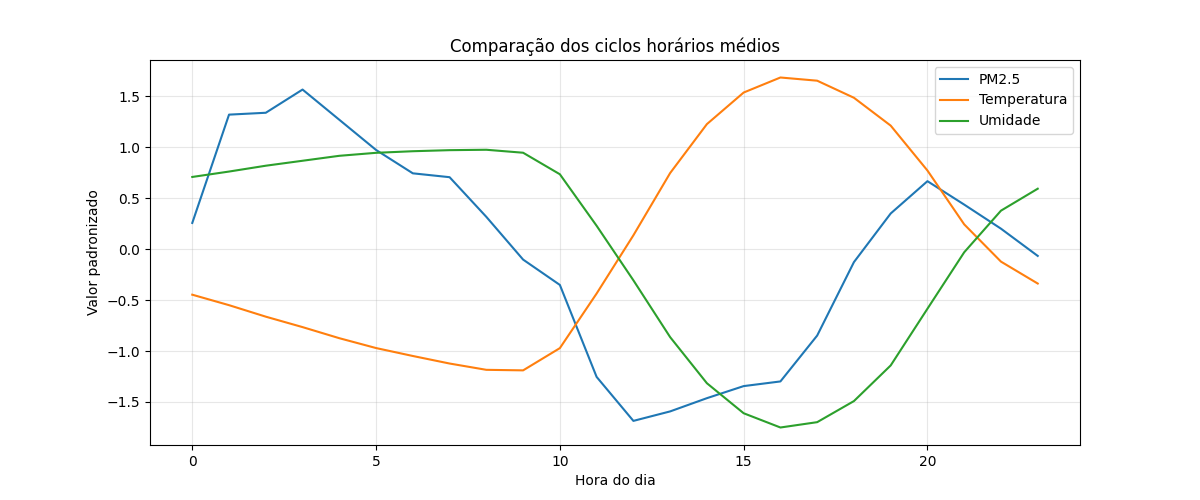

In [7]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

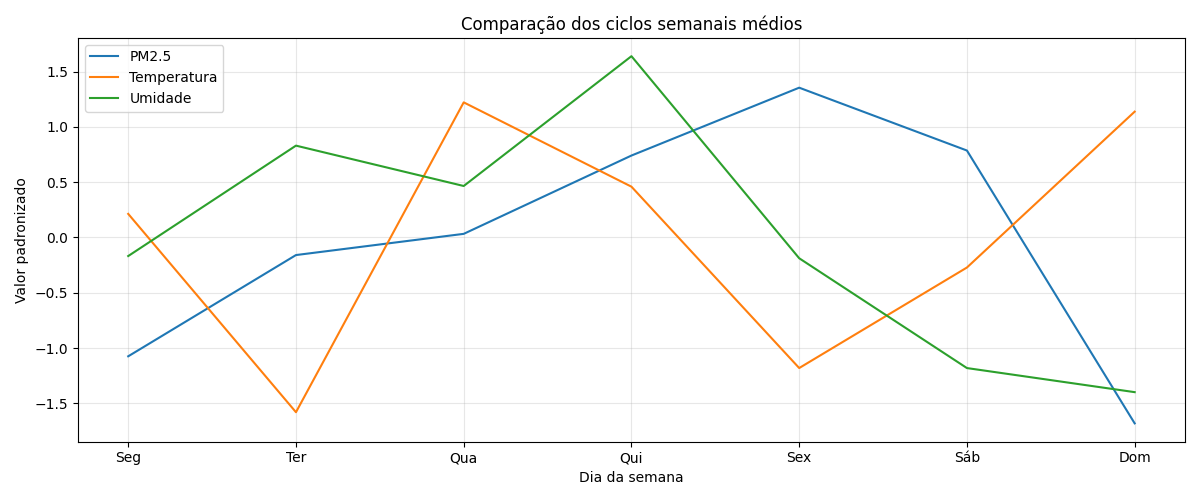

In [8]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

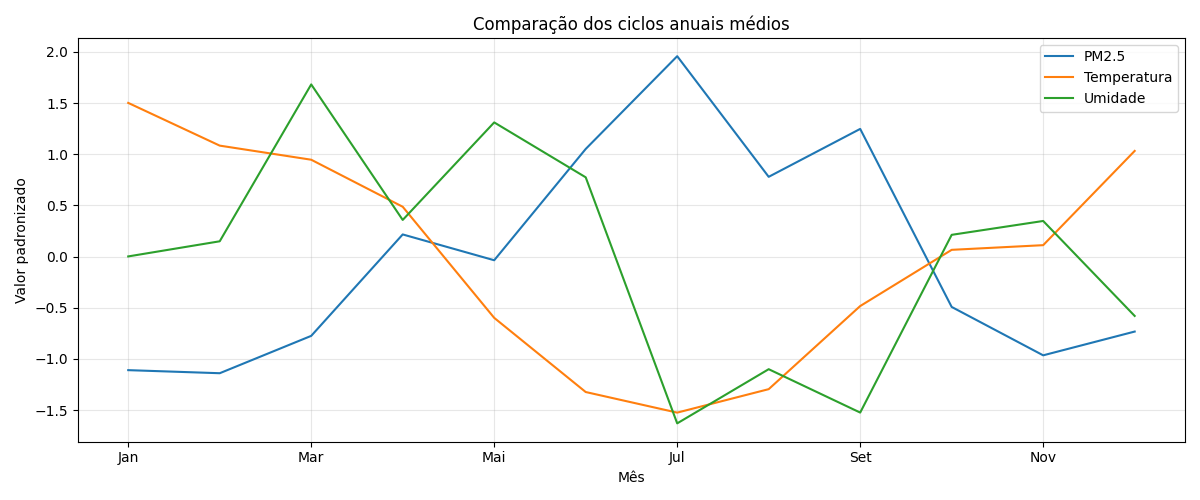

In [9]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [10]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

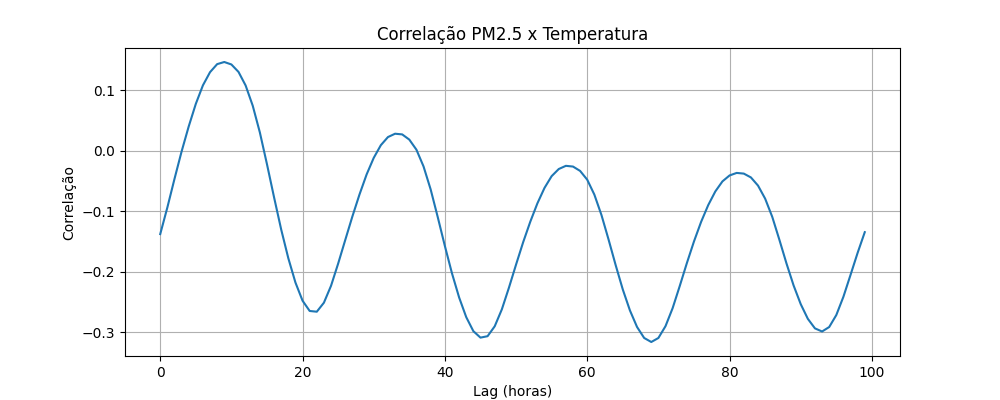

In [11]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [12]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

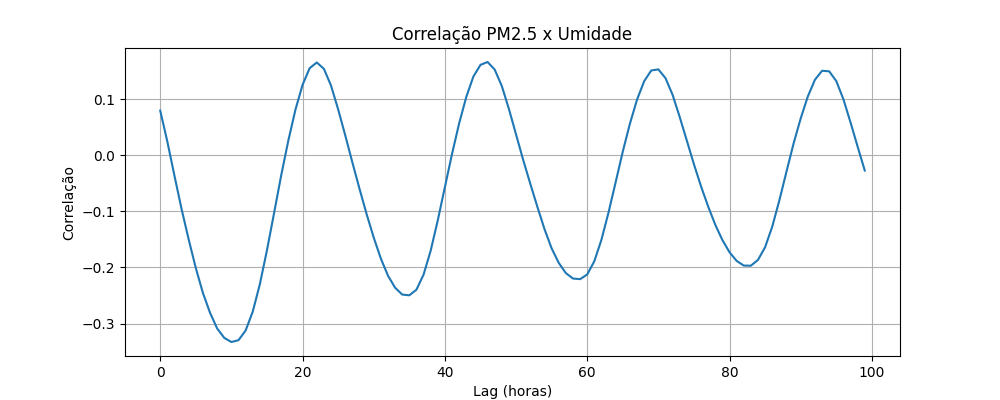

In [13]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [14]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

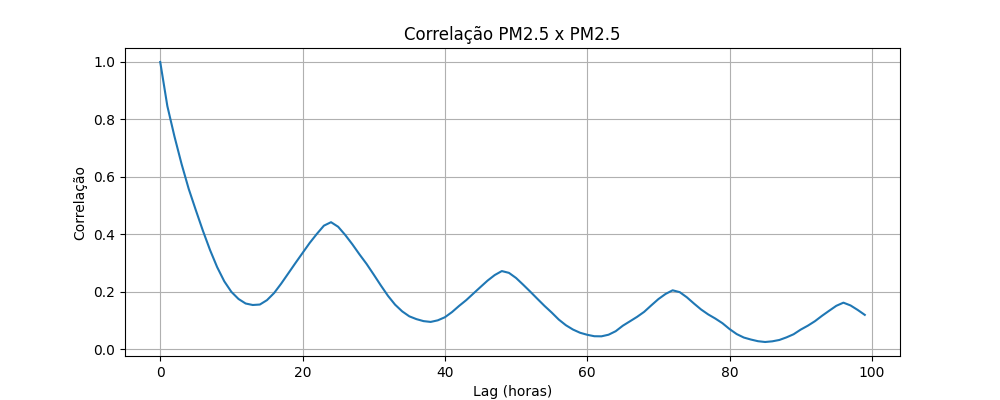

In [15]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [16]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi_temp = []

for lag in range(0, 100):

    c = data["temperature_2m"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi_temp.append(c)

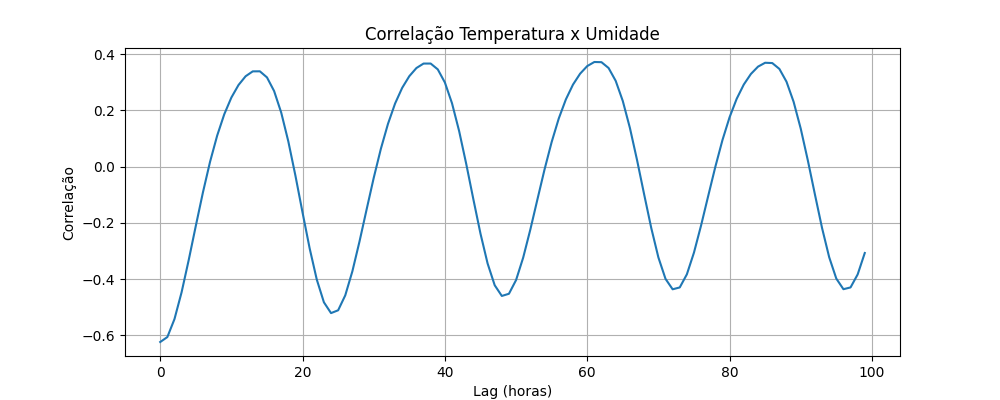

In [17]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação Temperatura x Umidade")
plt.grid()

plt.show()

### 4. VIF (Variance Inflation Factor): Investigando multicolinearidade entre as features

In [18]:
# normalizando utilizando StandardScaler()
cols = [
    "temperature_2m",
    "relative_humidity_2m"
]

scaler = StandardScaler()

data_scaled = data.drop(columns=["MP2.5"]).copy()
#data_scaled = data.copy()

data_scaled[cols] = scaler.fit_transform(
    data_scaled[cols]
)

data_scaled.head()

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,
2016-03-01 00:00:00+00:00,-0.303972,0.807668,1.0,12.538134
2016-03-01 01:00:00+00:00,-0.292856,0.867885,0.4,14.529915
2016-03-01 02:00:00+00:00,-0.281741,0.827881,0.3,12.538134
2016-03-01 03:00:00+00:00,-0.303972,0.887937,0.6,11.525623
2016-03-01 04:00:00+00:00,-0.292856,0.867885,0.5,12.979984


In [19]:
#Considerar VIF ≥  10 como um potencial problema

df = pd.DataFrame()

df["features"] = data_scaled.columns

df["vif_index"] = [vif(data_scaled.values, i) for i in range(data_scaled.shape[1])]

round(df.sort_values(by="vif_index", ascending = False),2)

,features,vif_index
1,relative_humidity_2m,1.68
0,temperature_2m,1.67
2,precipitation,1.07
3,wind_speed_10m,1.06


### 5. Entendendo estacionaridade e defasegem de PM2.5

In [20]:
# Avaliando período máximo contínuo sem gaps temporais para análise.
# Tentei fazer a análise com a série completa mas como tem gaps quis comparar também com uma série contínua
# para ter certeza que os gaps não estavam influenciando as estimativas, principalmente da estacionaridade.

def encontrar_segmentos_continuos(df, col="MP2.5", freq="h"):
    serie = df[col].copy()

    serie = serie.sort_index().asfreq(freq)

    valido = serie.notna()

    grupo = (valido != valido.shift()).cumsum()

    segmentos = []

    for _, bloco in serie.groupby(grupo):
        if bloco.notna().all():
            segmentos.append({
                "inicio": bloco.index[0],
                "fim": bloco.index[-1],
                "n_horas": len(bloco),
                "n_dias": len(bloco) / 24
            })

    segmentos = pd.DataFrame(segmentos)

    if segmentos.empty:
        return segmentos

    return segmentos.sort_values("n_horas", ascending=False).reset_index(drop=True)

In [21]:
segmentos = encontrar_segmentos_continuos(data, col="MP2.5", freq="h")
segmentos.head(10)

,inicio,fim,n_horas,n_dias
0,2016-11-08 18:00:00+00:00,2017-03-31 05:00:00+00:00,3420,142.500000
1,2019-03-05 17:00:00+00:00,2019-05-30 11:00:00+00:00,2059,85.791667
2,2018-12-26 15:00:00+00:00,2019-03-05 14:00:00+00:00,1656,69.000000
3,2017-11-07 14:00:00+00:00,2018-01-14 19:00:00+00:00,1638,68.250000
4,2017-05-04 17:00:00+00:00,2017-07-10 12:00:00+00:00,1604,66.833333
5,2018-04-05 12:00:00+00:00,2018-06-04 22:00:00+00:00,1451,60.458333
6,2018-01-17 03:00:00+00:00,2018-03-14 22:00:00+00:00,1364,56.833333
7,2016-07-17 12:00:00+00:00,2016-08-31 10:00:00+00:00,1079,44.958333
8,2016-05-01 16:00:00+00:00,2016-06-10 02:00:00+00:00,947,39.458333
9,2018-06-19 03:00:00+00:00,2018-07-24 19:00:00+00:00,857,35.708333


In [22]:
maior = segmentos.iloc[0]

inicio = maior["inicio"]
fim = maior["fim"]

data_continua = data.loc[inicio:fim].copy()

print(inicio, fim)
print(f"{maior['n_dias']:.1f} dias contínuos")

2016-11-08 18:00:00+00:00 2017-03-31 05:00:00+00:00
142.5 dias contínuos


In [23]:
# Avaliando impactos diretos e indiretos de PM2.5
def plot_autocorrelation(y, d=0, D=0, m=0):
    y = pd.Series(y)
    if D > 0:
        for i in range(D):
            y = y.diff(m)
    if d > 0:
        for i in range(d):
            y = y.diff(1)
    fig = plt.figure(figsize=(20,10))
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,2,3)
    ax3 = fig.add_subplot(2,2,4)
    ax1.plot(y)
    plot_acf(y, lags = 50, ax=ax2);
    plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
    plt.show()

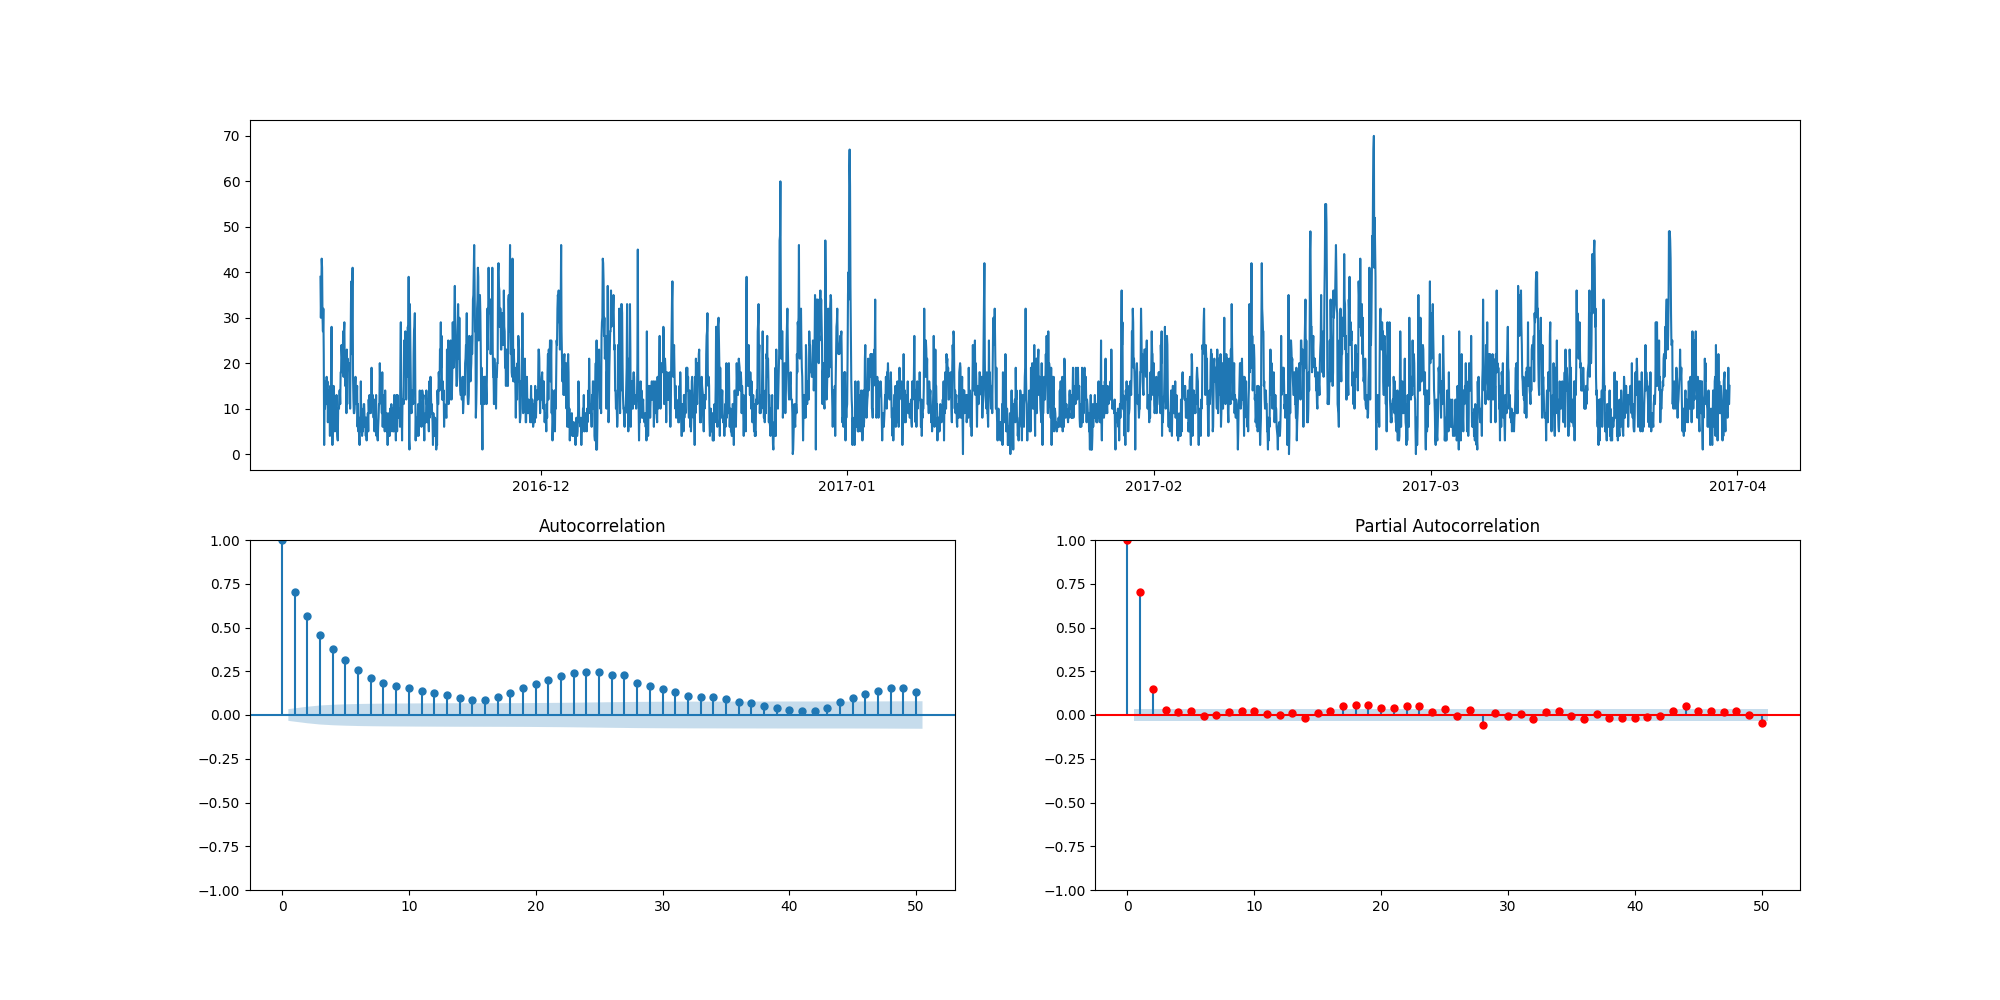

In [24]:
plot_autocorrelation(data_continua["MP2.5"], d=0, D=0, m=24)

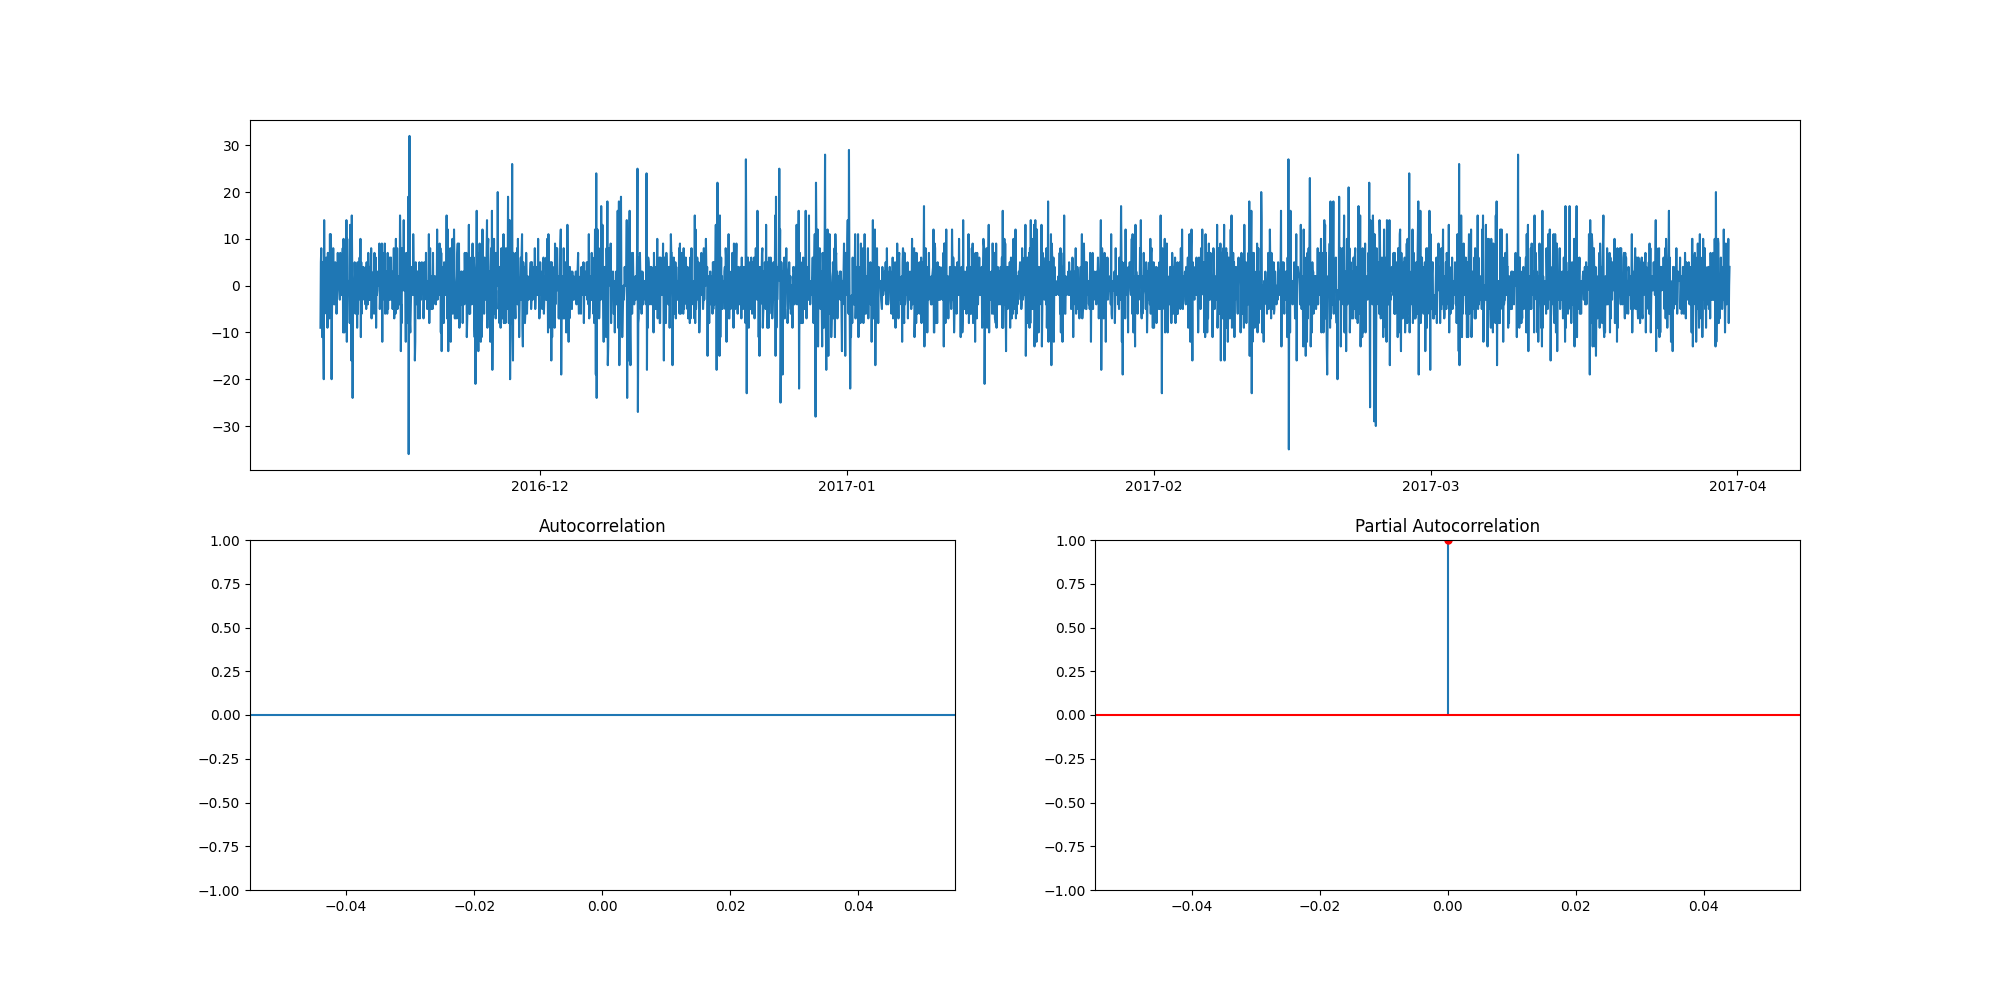

In [25]:
plot_autocorrelation(data_continua["MP2.5"],d=1,D=0,m=24)

Avaliando a Estacionaridade

**************
O p-valor deve ser menor que 0,05 para que possamos ter 95% de confiança de que a série é estacionária.

Idealmente, o p-valor deve ser muito menor que 0,05.
*************
seasonal_order=(P,1,Q,24)

In [26]:
result = adfuller(data_continua["MP2.5"])

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -6.677629191689672
p-value: 4.423892863798992e-09


### 6. Separando conjunto de treino e teste

In [27]:
metade = int(len(data) * 0.5)
#data_50 = data.iloc[:metade]
data_50 = data.iloc[-metade:].copy()
train_size = 0.7
index = int(train_size * len(data_50))

df_train = data_50.iloc[:index].copy()
df_test = data_50.iloc[index:].copy()

y = data_50["MP2.5"]
y_train = df_train["MP2.5"]
y_test = df_test["MP2.5"]

cols_exog = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"
]

exog = data_50[cols_exog]
exog_train = df_train[cols_exog]
exog_test = df_test[cols_exog]

In [28]:
from dateutil.relativedelta import relativedelta

print(f'Intevalo de treino: {y_train.index[0]} a {y_train.index[-1]}')
diff = relativedelta(y_train.index[-1], y_train.index[0])
print(diff)

print(f'Intevalo de teste: {y_test.index[0]} a {y_test.index[0]}')
diff = relativedelta(y_test.index[-1], y_test.index[0])
print(diff)

Intevalo de treino: 2017-11-23 14:00:00+00:00 a 2019-02-09 07:00:00+00:00
relativedelta(years=+1, months=+2, days=+16, hours=+17)
Intevalo de teste: 2019-02-09 08:00:00+00:00 a 2019-02-09 08:00:00+00:00
relativedelta(months=+6, days=+8, hours=+18)


In [29]:
print("data_50:", data_50.shape, data_50.index[0], data_50.index[-1])
print("train:", y_train.shape, y_train.index[0], y_train.index[-1])
print("test :", y_test.shape, y_test.index[0], y_test.index[-1])

data_50: (15181, 5) 2017-11-23 14:00:00+00:00 2019-08-18 02:00:00+00:00
train: (10626,) 2017-11-23 14:00:00+00:00 2019-02-09 07:00:00+00:00
test : (4555,) 2019-02-09 08:00:00+00:00 2019-08-18 02:00:00+00:00


### 7. Baseline simples

In [30]:
# Seasonal Naive (24h)
# observado nas primeiras 24h do teste
y_true = y_test.iloc[:24]

# Baseline = ultimas 24h do treino
y_baseline = y_train.iloc[-24:].copy()

y_baseline.index = y_true.index

mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = root_mean_squared_error(y_true, y_baseline)
r2_baseline = r2_score(y_true, y_baseline)

print(f"Baseline 24h - MAE : {mae_baseline:.3f}")
print(f"Baseline 24h - RMSE: {rmse_baseline:.3f}")
print(f"Baseline 24h - R²  : {r2_baseline:.3f}")

Baseline 24h - MAE : 6.667
Baseline 24h - RMSE: 8.251
Baseline 24h - R²  : -2.155


### 8. Modelagem

  Ref. https://skforecast.org/latest/user_guides/forecasting-sarimax-arima.html

  https://www.geeksforgeeks.org/python/complete-guide-to-sarimax-in-python/



In [31]:
# p=2 (PACF), d=0 (estacionaria), q=1 (ACF), m=24 (ciclo diário é o meu forte) - exp.1
# p=2 (PACF), d=1 (diferenciação sazonal), q=1 (ACF), m=24 (ciclo diário é o meu forte) - exp.2
order = (3,1,1)
seasonal_order = (0,1,1,24)

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order
)

/home/izabel/.pyenv/versions/respira_sp/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/izabel/.pyenv/versions/respira_sp/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [32]:
results = model.fit()

/home/izabel/.pyenv/versions/respira_sp/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [33]:
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              MP2.5   No. Observations:                10626
Model:             SARIMAX(3, 1, 1)x(0, 1, 1, 24)   Log Likelihood              -32946.109
Date:                            Wed, 17 Jun 2026   AIC                          65912.218
Time:                                    12:55:16   BIC                          65984.905
Sample:                                11-23-2017   HQIC                         65936.750
                                     - 02-09-2019                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
temperature_2m          -0.1060      0.124     -0.858      0.391      -0.348       0.136
relat

In [34]:
# previsão das próximas 24h
forecast_24h = results.get_forecast(
    steps=24,
    exog=exog_test.iloc[:24]
)

forecast_mean = forecast_24h.predicted_mean
conf_int = forecast_24h.conf_int()

index_forecast = y_test.index[:24]

forecast_mean.index = index_forecast
conf_int.index = index_forecast

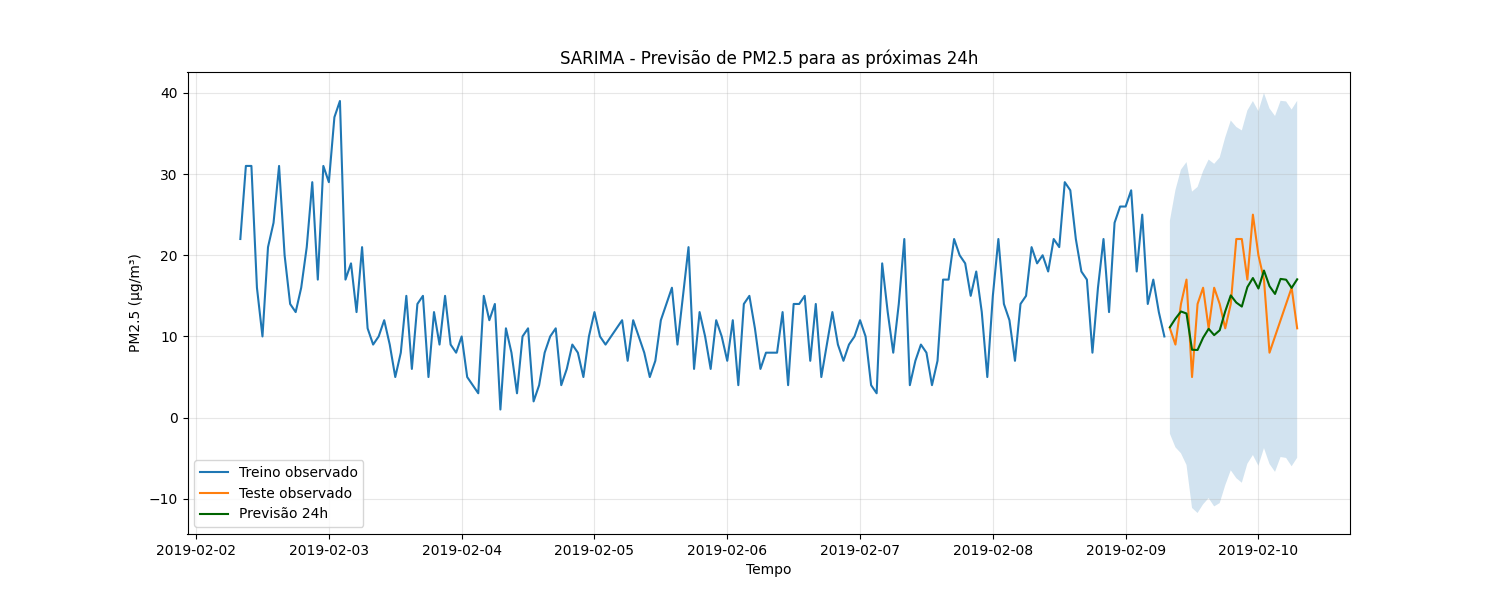

In [35]:
# Figura
plt.figure(figsize=(15, 6))

# últimos dias observados
plt.plot(
    y_train.iloc[-24*7:],
    label="Treino observado"
)

# comparar somente com +24h
plt.plot(
    y_test.iloc[:24],
    label="Teste observado"
)


plt.plot(
    forecast_mean,
    label="Previsão 24h",
    color="darkgreen"
)


plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)

plt.title("SARIMA - Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
error_mae = mean_absolute_error(
                y_true = y_test.iloc[:24],
                y_pred = forecast_mean
            )
print(f"Test error (mae): {error_mae}")

Test error (mae): 3.8979385005053917


In [37]:
error_rmse = root_mean_squared_error(
    y_true=y_test.iloc[:24],
    y_pred=forecast_mean
)

print(f"Test error (RMSE): {error_rmse:.3f}")

Test error (RMSE): 4.726


In [38]:
r2 = r2_score(
    y_true=y_test.iloc[:24],
    y_pred=forecast_mean
)

print(f"R²: {r2:.4f}")

R²: -0.0349


### 9. Experimentos - Resultados



**Testes do conjunto de dados, features, interpolações**

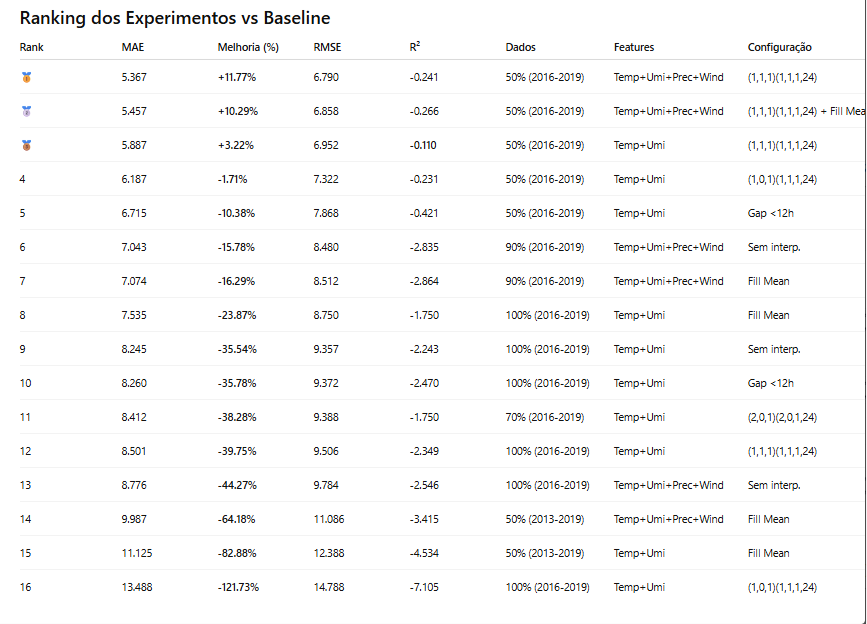

**Testes dos parâmetros do SARIMAX usando melhor conjunto de dados/features/interpolação**

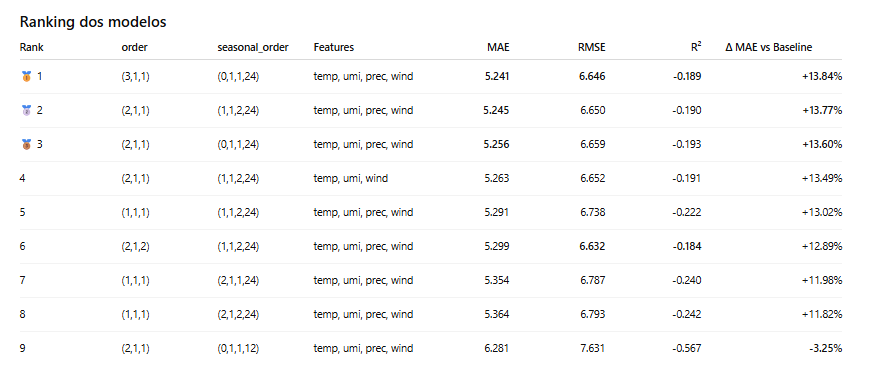

***Teste de dados mais recentes e intervalo de treinamento***

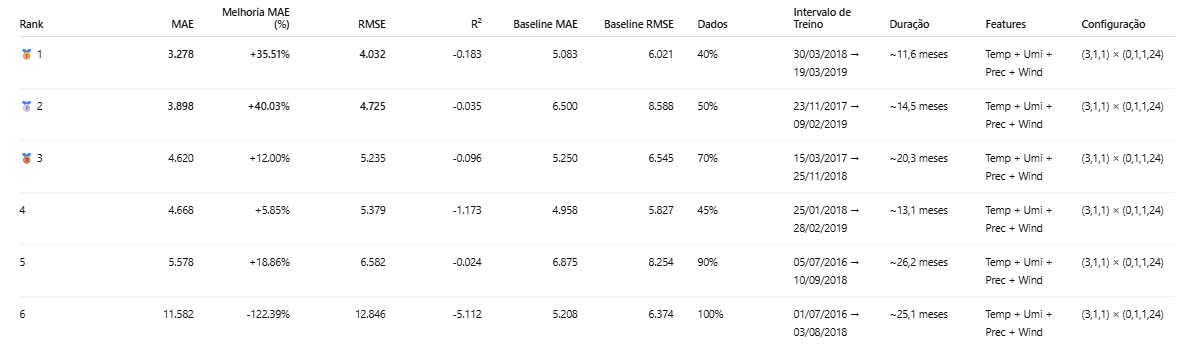

**Avaliando base de treino expandindo as previsões para um ano de referência - verificação de vies temporal na validação**

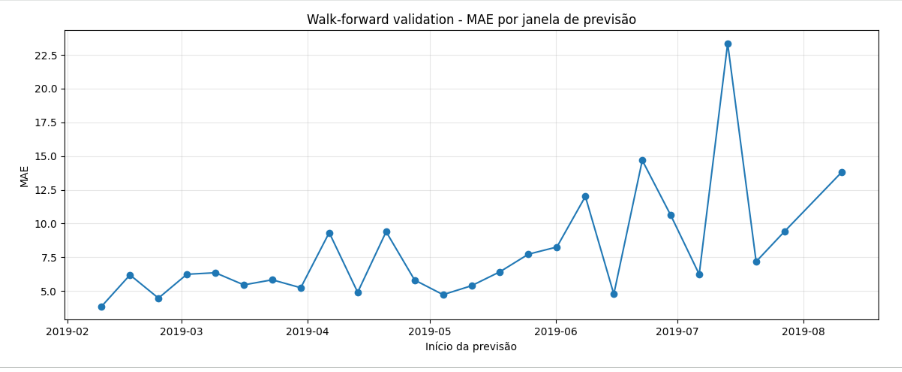

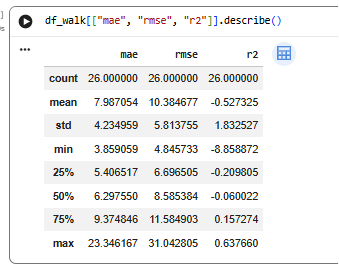

***Experimentos com dados mais recentes e intervalo de treinamento***

In [39]:
experimentos = {
    "exp_01": {
        "duracao_meses": 14.5,
        "mae": 3.898,
        "rmse": 4.725,
        "r2": -0.035,
        "baseline_mae": 6.500,
        "baseline_rmse": 8.588
    },

    "exp_02": {
        "duracao_meses": 20.3,
        "mae": 4.620,
        "rmse": 5.235,
        "r2": -0.096,
        "baseline_mae": 5.250,
        "baseline_rmse": 6.545
    },

    "exp_03": {
        "duracao_meses": 26.2,
        "mae": 5.578,
        "rmse": 6.582,
        "r2": -0.024,
        "baseline_mae": 6.875,
        "baseline_rmse": 8.254
    },

    "exp_04": {
        "duracao_meses": 11.6,
        "mae": 3.278,
        "rmse": 4.032,
        "r2": -0.183,
        "baseline_mae": 5.083,
        "baseline_rmse": 6.021
    },

    "exp_05": {
        "duracao_meses": 13.1,
        "mae": 4.668,
        "rmse": 5.379,
        "r2": -1.173,
        "baseline_mae": 4.958,
        "baseline_rmse": 5.827
    },

    "exp_06": {
        "duracao_meses": 25.1,
        "mae": 11.582,
        "rmse": 12.846,
        "r2": -5.112,
        "baseline_mae": 5.208,
        "baseline_rmse": 6.374
    }
}

In [40]:
df = pd.DataFrame(experimentos).T

df["melhoria_mae_pct"] = (
    (df["baseline_mae"] - df["mae"])
    / df["baseline_mae"]
) * 100

df["melhoria_rmse_pct"] = (
    (df["baseline_rmse"] - df["rmse"])
    / df["baseline_rmse"]
) * 100

df.head()

,duracao_meses,mae,rmse,r2,baseline_mae,baseline_rmse,melhoria_mae_pct,melhoria_rmse_pct
exp_01,14.5,3.898,4.725,-0.035,6.500,8.588,40.030769,44.981369
exp_02,20.3,4.620,5.235,-0.096,5.250,6.545,12.000000,20.015279
exp_03,26.2,5.578,6.582,-0.024,6.875,8.254,18.865455,20.256845
exp_04,11.6,3.278,4.032,-0.183,5.083,6.021,35.510525,33.034380
exp_05,13.1,4.668,5.379,-1.173,4.958,5.827,5.849133,7.688347


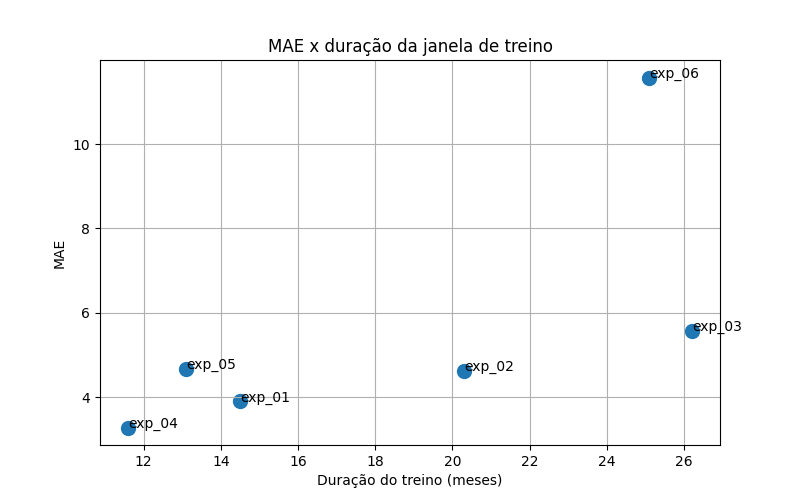

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["duracao_meses"],
    df["mae"],
    s=100
)

for idx, row in df.iterrows():
    plt.annotate(
        idx,
        (row["duracao_meses"], row["mae"])
    )

plt.xlabel("Duração do treino (meses)")
plt.ylabel("MAE")
plt.title("MAE x duração da janela de treino")
plt.grid(True)

plt.show()

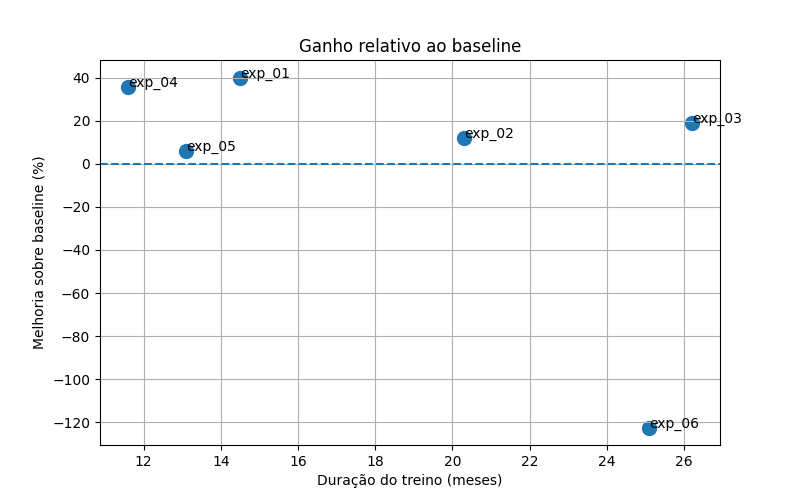

In [42]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["duracao_meses"],
    df["melhoria_mae_pct"],
    s=100
)

for idx, row in df.iterrows():
    plt.annotate(
        idx,
        (row["duracao_meses"], row["melhoria_mae_pct"])
    )

plt.axhline(0, ls="--")

plt.xlabel("Duração do treino (meses)")
plt.ylabel("Melhoria sobre baseline (%)")
plt.title("Ganho relativo ao baseline")
plt.grid(True)

plt.show()

### 10. Mémória de Cálculo (Experimentos)

**********
Experimentos no computador
*******

Experimento 01 - 70% dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)

    seasonal_order=(2,0,1,24)
    Test error (mae): 8.411993014511117
    Test error (RMSE): 9.388
    R²: -1.7497


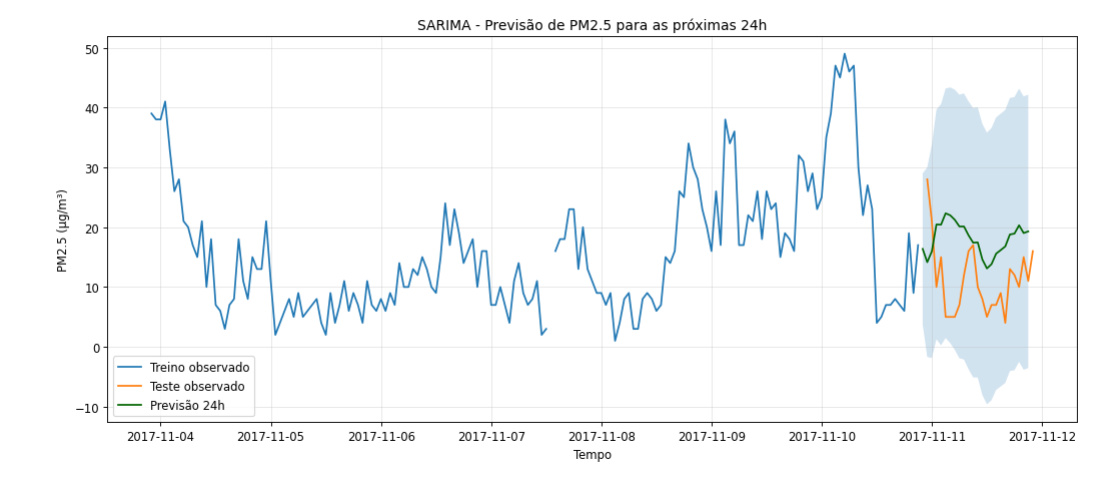




Experimento 02 - 50% dos dados dos dados (2016-2019), com interpolar (<12h>), usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,0,1)

Test error (mae): 6.715100410694242
Test error (RMSE): 7.868
R²: -0.4212

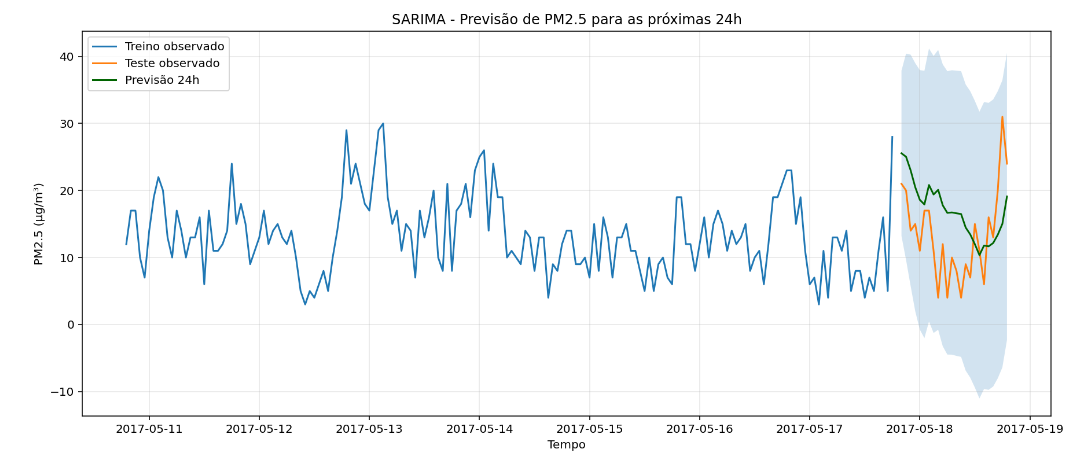

Experimento 3: 50% dos dados dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,0,1)

Test error (mae): 6.187498440177535
Test error (RMSE): 7.322
R²: -0.2310

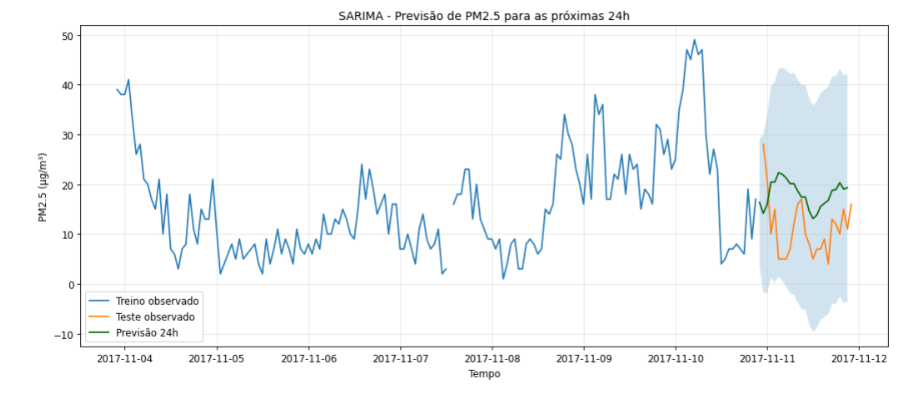

Experiemento 4: 50% dos dados dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.887462509112564
Test error (RMSE): 6.952
R²: -0.1095

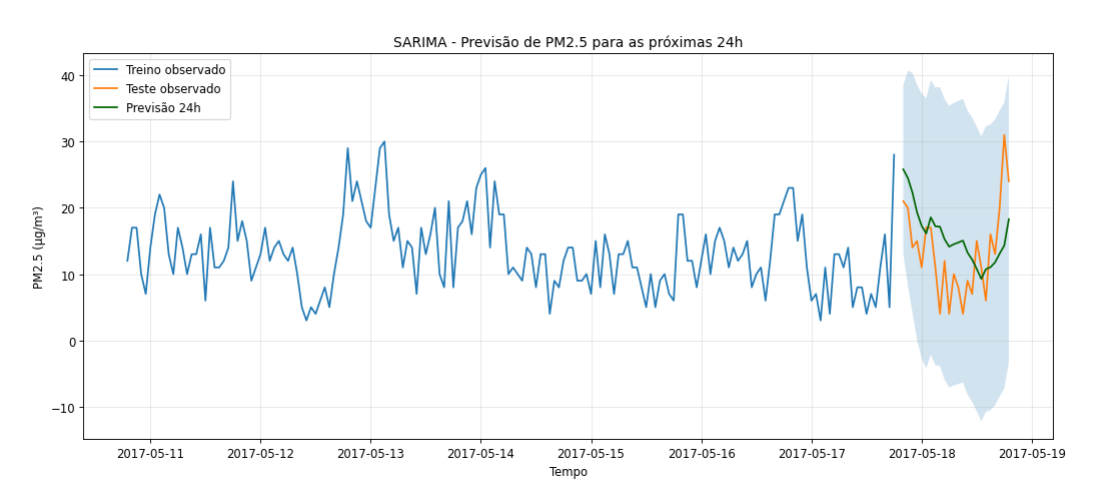

********
Google colab (temp,umi)
*******

Experimento 01: 100% do conjunto de dados de 2016-2019 sem interlação
seasonal_order = (1,1,1,24)
order = (1,1,1)

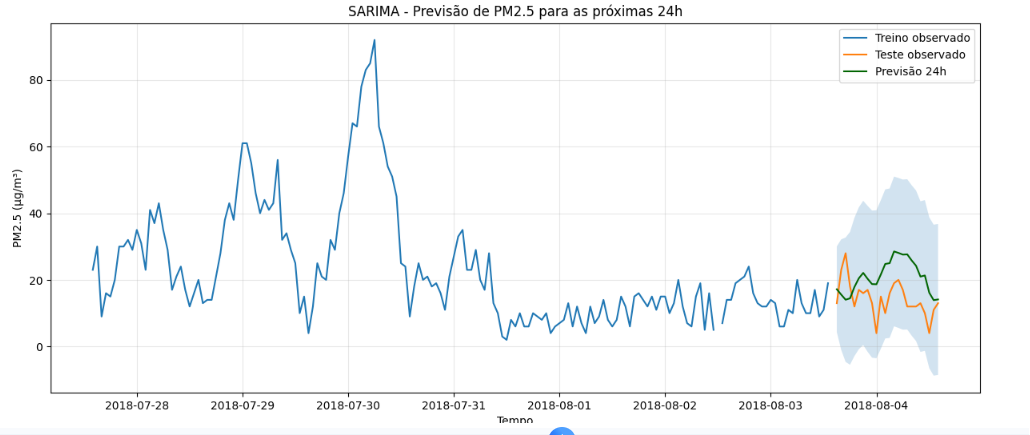

Test error (mae): 8.501113288421886
Test error (RMSE): 9.506
R²: -2.3490

Experimenti 02: 100% do conjunto de dados de 2016-2019 sem interpolação seasonal_order = (1,1,1,24)
order = (1,0,1)

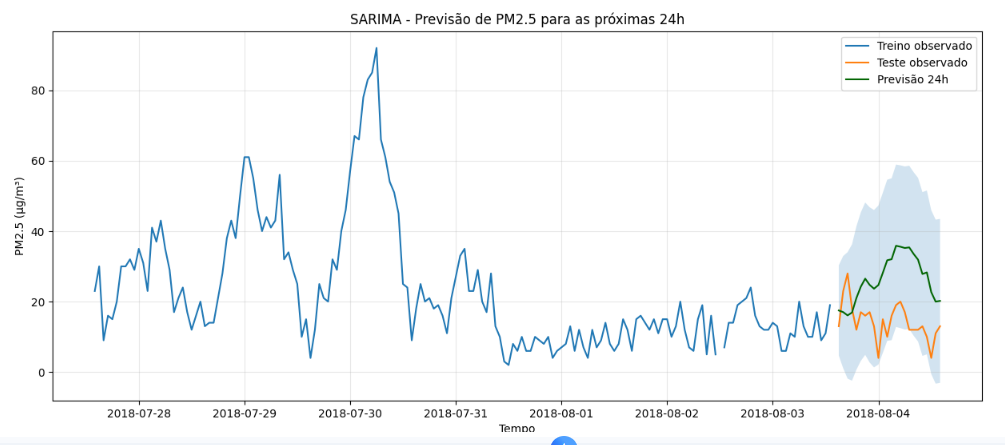

Test error (mae): 13.488402735453173
Test error (RMSE): 14.788
R²: -7.1045

Experimento 03: 100% do conjunto de dados de 2016-2019 sem interpolação 
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 8.245248937691105
Test error (RMSE): 9.357
R²: -2.2425

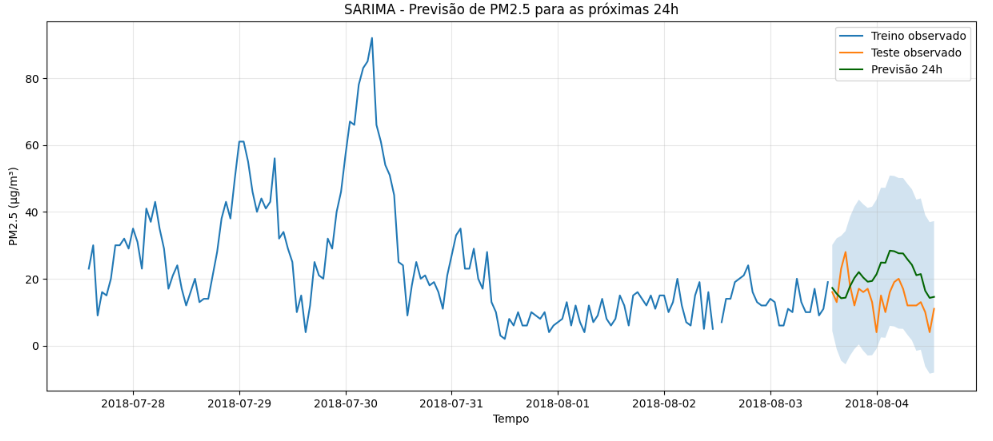

Experimento 4: 100% dos dados de 2016-2019, dados com interpolação (fill mean) sazonal seasonal_order = (1,1,1,24)
order = (1,1,1)


Test error (mae): 7.535035896153052
Test error (RMSE): 8.750
R²: -1.7497

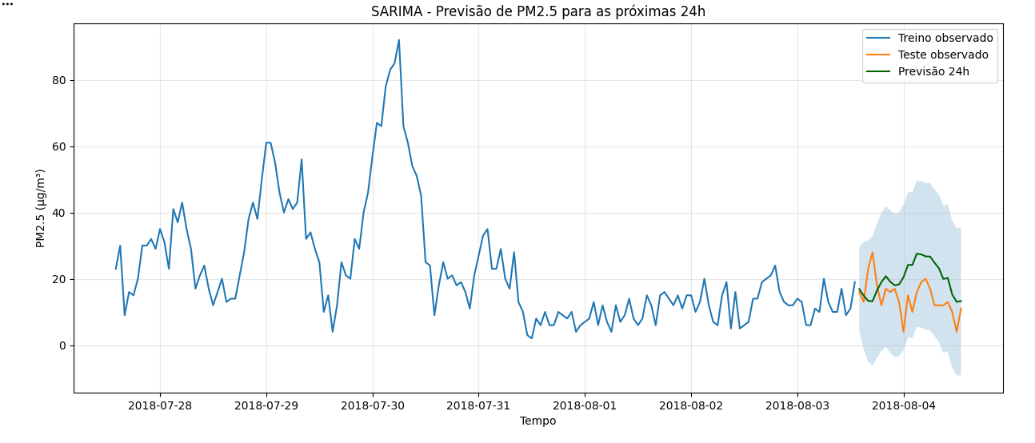

Experimento 5: 100% dos dados de 2016-2019 com interpolação (gap <12h), seasonal_order = (1,1,1,24)
order = (1,1,1)


Test error (mae): 8.26007769966428
Test error (RMSE): 9.372
print(f"R²: {r2:.4f}")

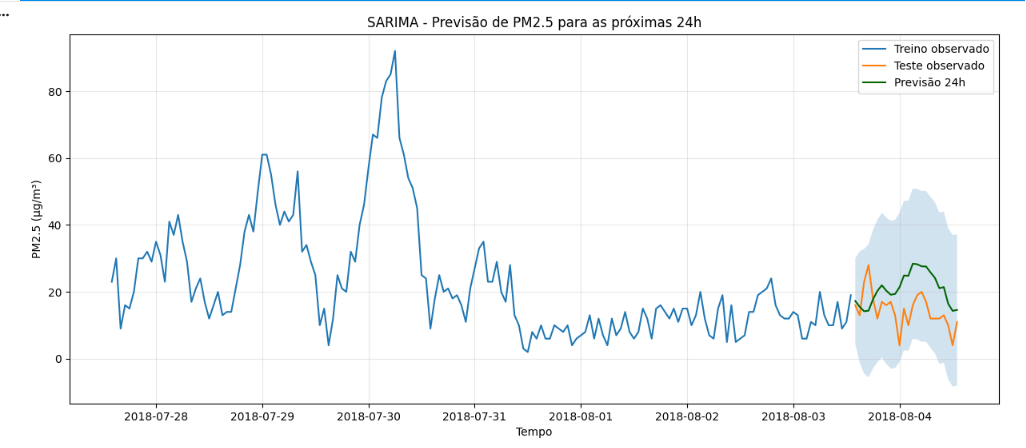

****
Google Colab com todas as features (temp, umi, prec, wind)
****

Experimento01: 100% dos dados, 2016 - 2019, sem interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 8.775777652179265

Test error (RMSE): 9.784

R²: -2.5458

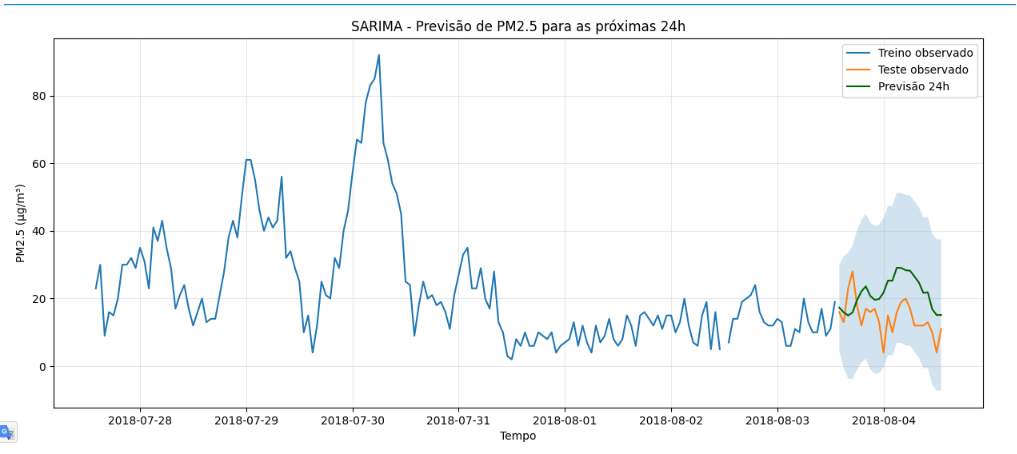

Experimento02: 90% dos dados, 2016 - 2019, com interpolação full interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 7.073693232210059
Test error (RMSE): 8.512
R²: -2.8642


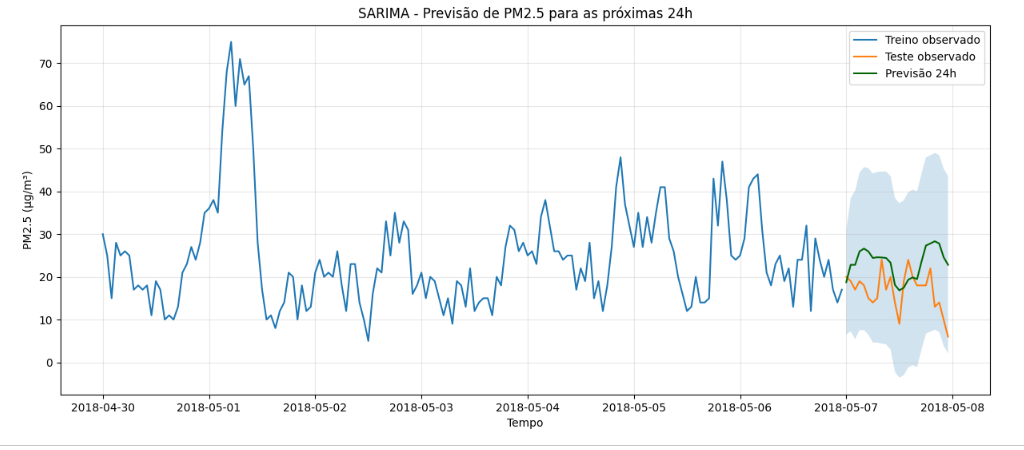

Experimento03: 90% dos dados, 2016 - 2019, sem interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 7.042980058925504
Test error (RMSE): 8.480
R²: -2.8354


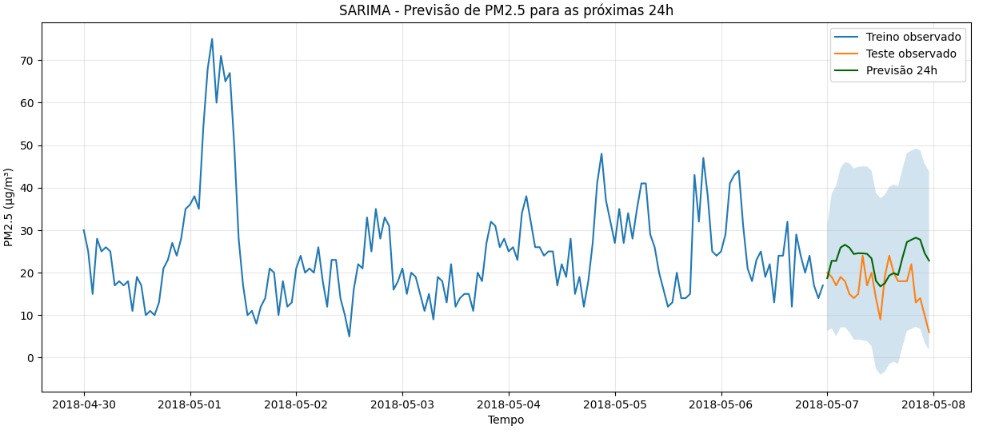

Experimento04: 50% dos dados, 2016 - 2019, sem interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.367382855182874
Test error (RMSE): 6.790
R²: -0.2408

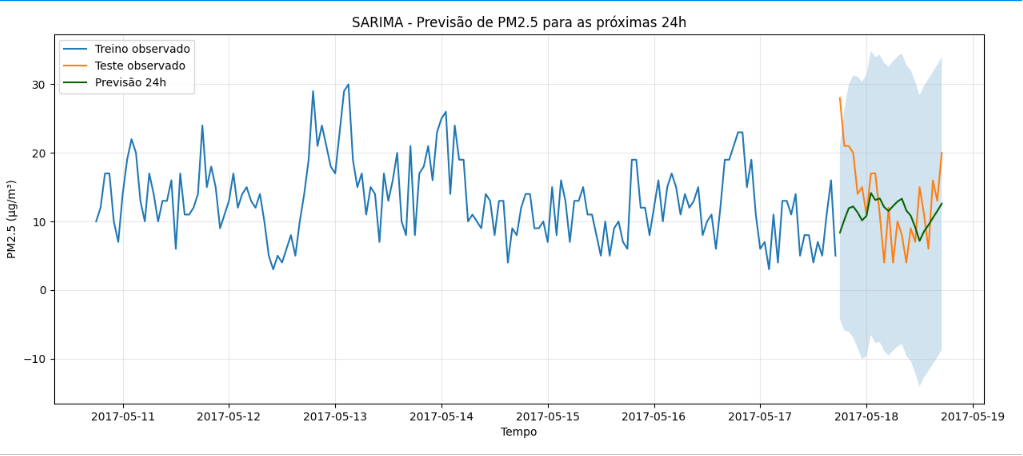

Experimento05: 50% dos dados, 2016 - 2019, interpolação (fill mean), features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.456949729972361
Test error (RMSE): 6.858
R²: -0.2655

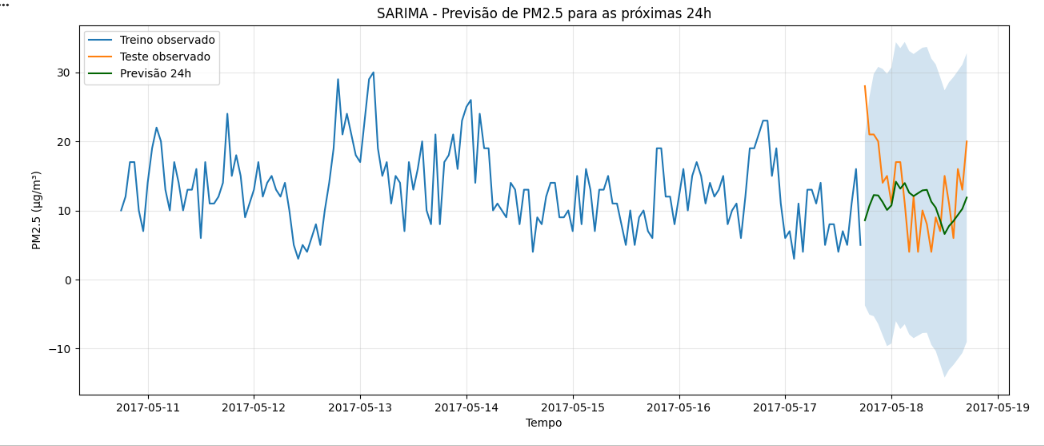

Experimento 06: 50% dos dados de 2016-2019, interpolação (fill mean), features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.456949729972361
Test error (RMSE): 6.858
R²: -0.2655

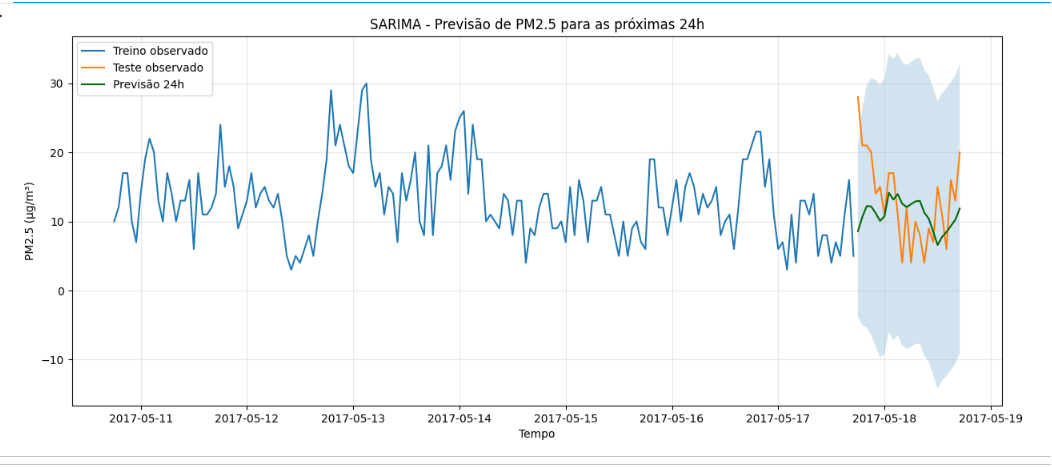

******
Colab - Dados 2013 - 2019 (temp,umi)
******

Experimento01: 50% dos dados, 2013 - 2019, interpolação (fill mean), seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 11.124666353320697
Test error (RMSE): 12.388
R²: -4.5336


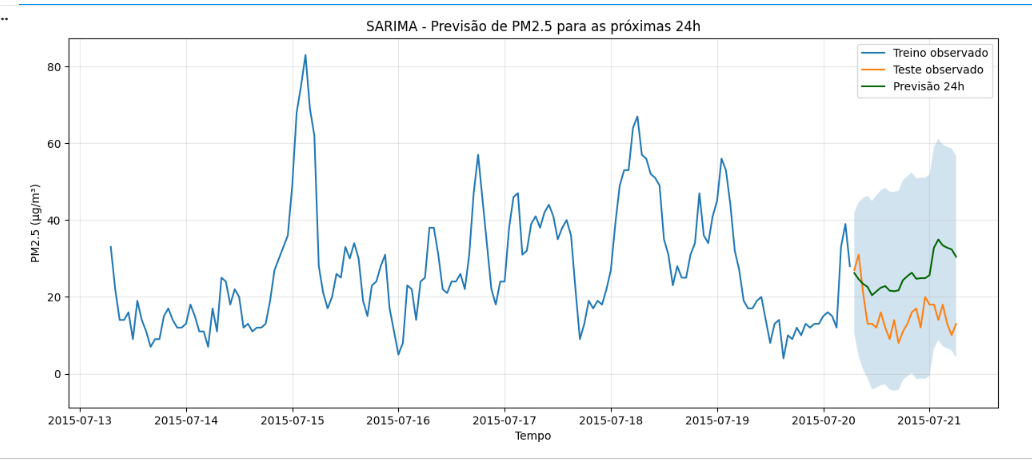

*****
Dados 2013 - 2019 (temp,umi, prec, vento)
*****

Experimento01: 50% dos dados, 2013 - 2019, full mean interpolação seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 9.875185811080355
Test error (RMSE): 11.066
R²: -3.4150

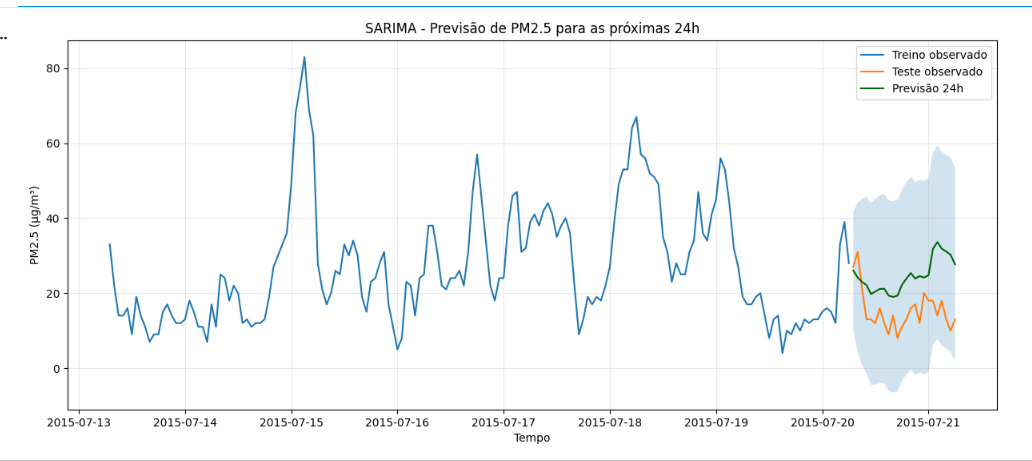



****
Testando parâmetros SARIMAX - estou tendo problema de memória com o GridSearch, vou fazer na mão os experimentos. 
****

Experimento 01: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)

    seasonal_order = (2,1,1,24)
    order = (1,1,1)

Test error (mae): 5.3543891361387566
Test error (RMSE): 6.787
R²: -0.2396

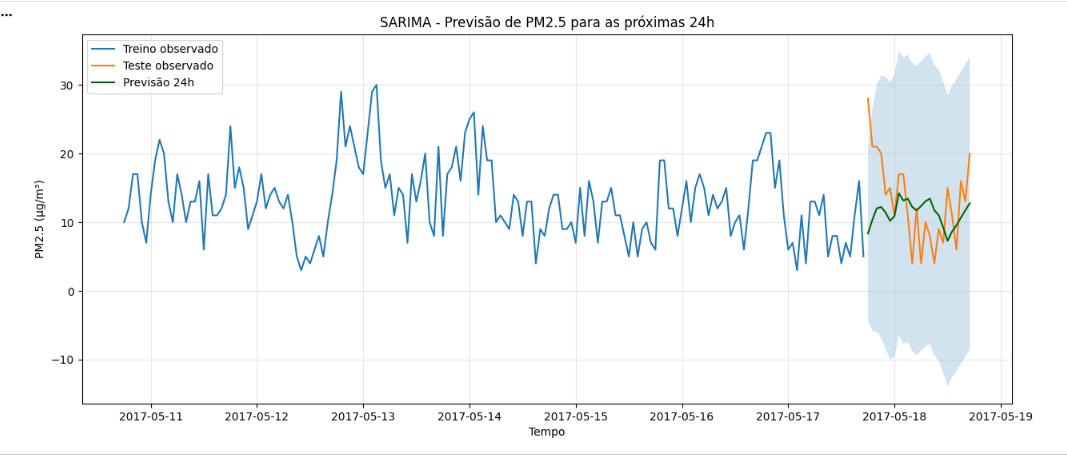

Experimento 02: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)

    seasonal_order = (1,1,2,24)
    order = (1,1,1)

Test error (mae): 5.2911476310784415
Test error (RMSE): 6.738
R²: -0.2218

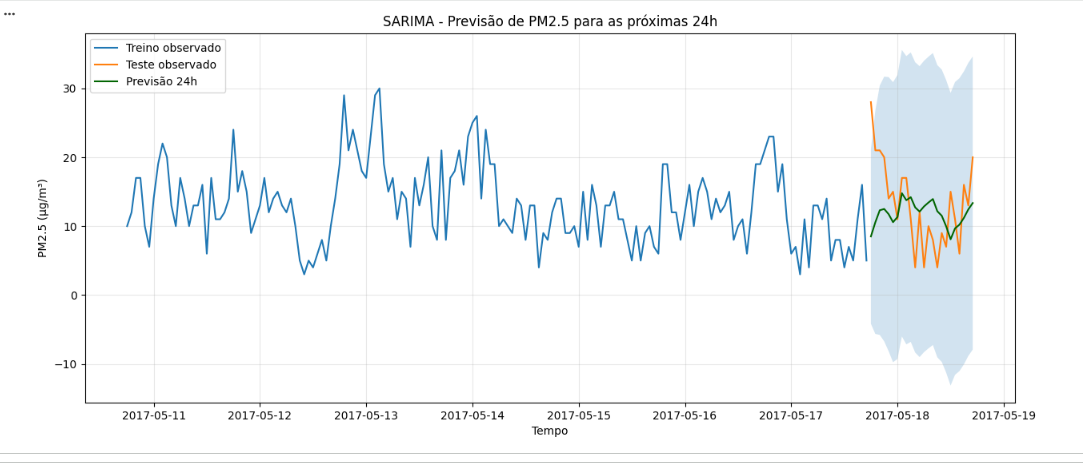

Experimento 03: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)

    seasonal_order = (2,1,2,24)
    order = (1,1,1)

Test error (mae): 5.364168252446791
Test error (RMSE): 6.793
R²: -0.2417

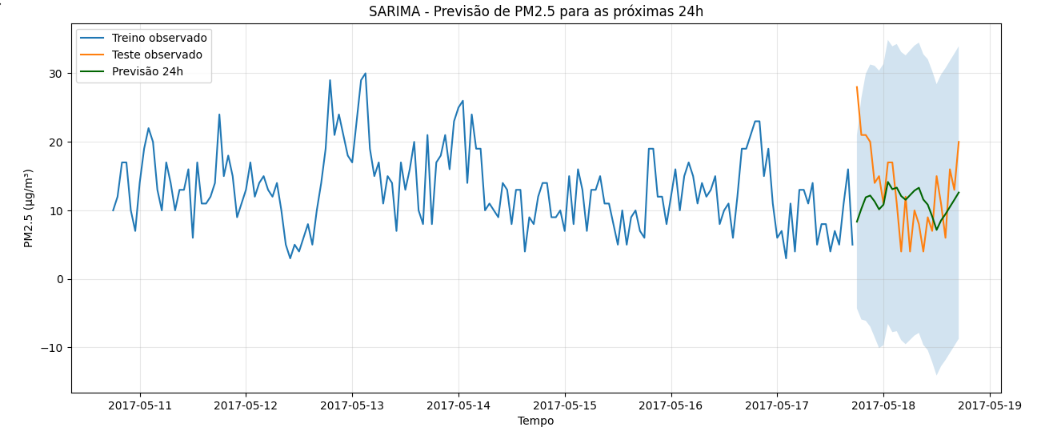

Experimento 04: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)

    order = (2,1,1)
    seasonal_order = (1,1,2,24)

Test error (mae): 5.244658180104289
Test error (RMSE): 6.650
R²: -0.1900

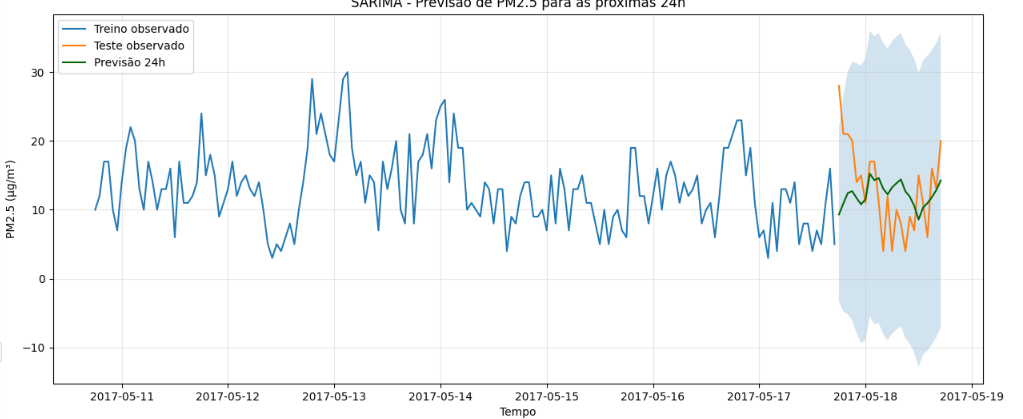

Experimento 05: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)

    order=(2,1,2)
    seasonal_order=(1,1,2,24)

Test error (mae): 5.298750228973242
Test error (RMSE): 6.632
R²: -0.1838

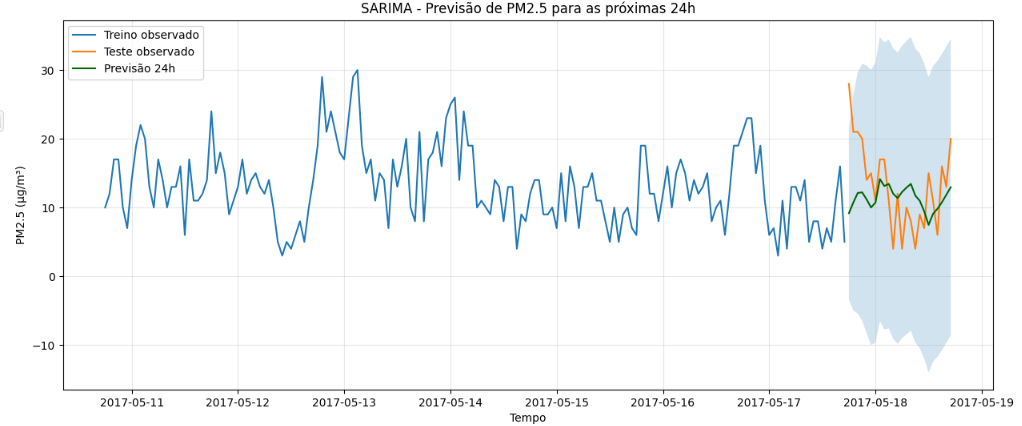

Experimento 06: Dados 2016-2019 (50%), sem interpolação, **features (temp, umi, wind)**
    order=(2,1,1)
    seasonal_order=(1,1,2,24)

Test error (mae): 5.26272118730893
Test error (RMSE): 6.652
R²: -0.1909

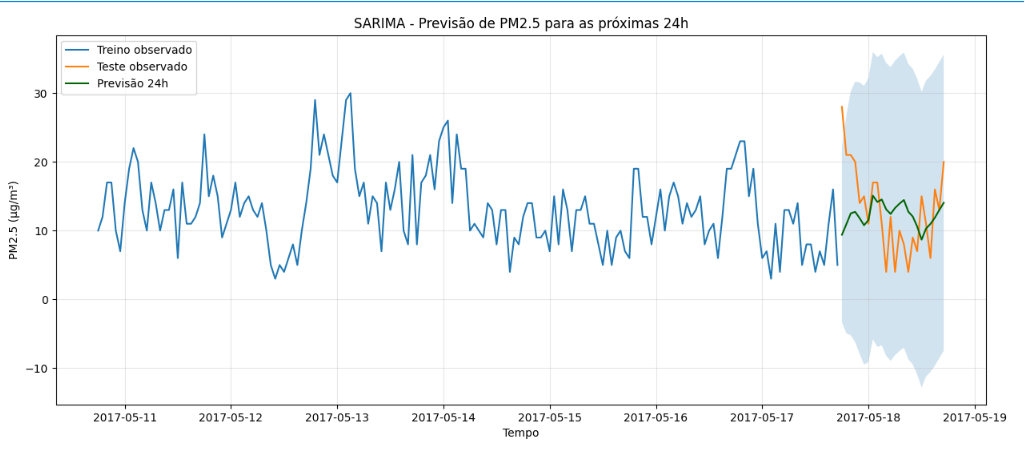

Experimento 07: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)
    order=(2,1,1)
    seasonal_order=(0,1,1,24)

Test error (mae): 5.255936456550331
Test error (RMSE): 6.659
R²: -0.1933

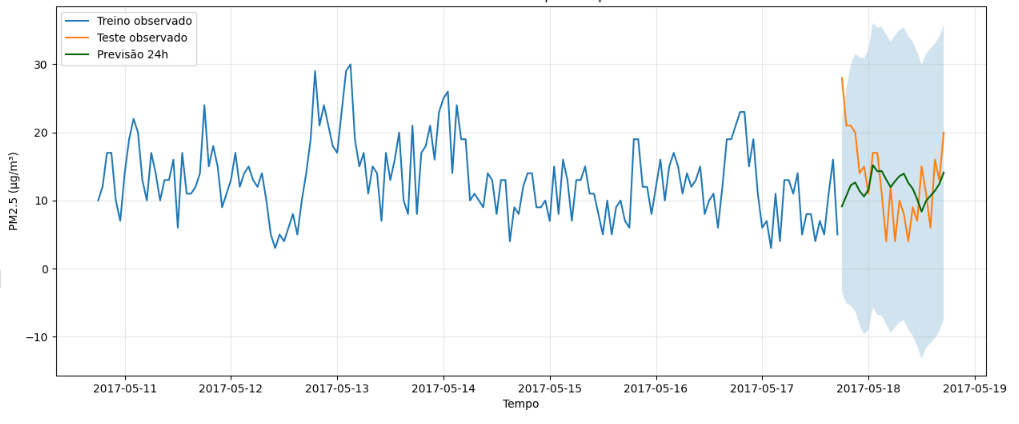

Experimento 08: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)

    order=(3,1,1)
    seasonal_order=(0,1,1,24)

Test error (mae): 5.241325989003906
Test error (RMSE): 6.646
R²: -0.1886

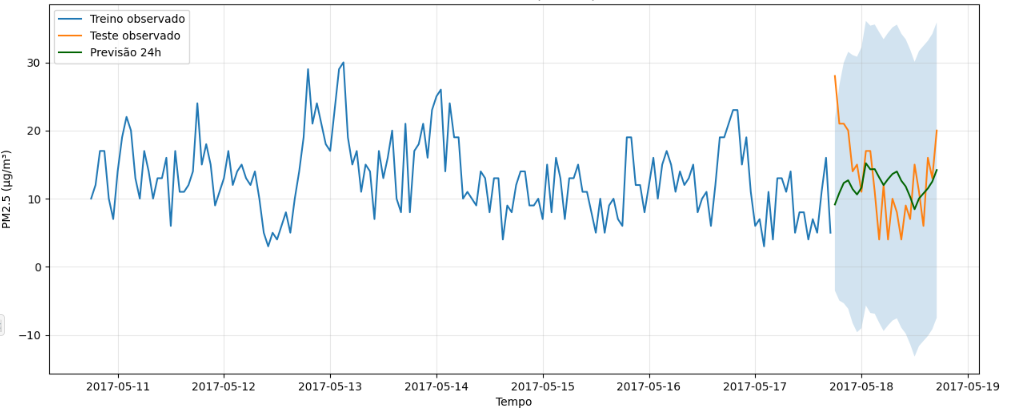

Experimento 09: Dados 2016-2019 (50%), sem interpolação, todas as features (temp, umi, prec, wind)

    order=(2,1,1)
    seasonal_order=(0,1,1,12)

Test error (mae): 6.280644757161331
Test error (RMSE): 7.631
R²: -0.5670

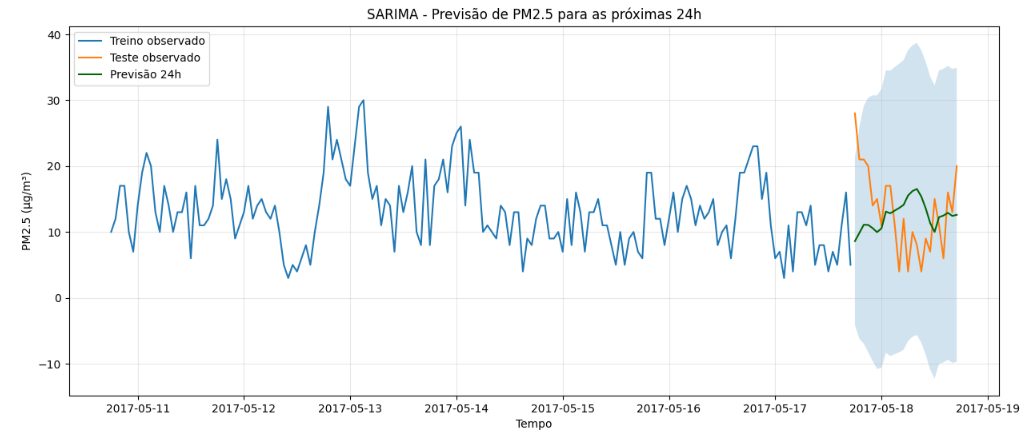

****
**Testando dados mais recentes**

Resultados parecem estar mais associados ao conjunto de dados que escolho para treinar do que os parâmetros.
****

Experimento 01: 50% dos dados, sem interpolação, todas as features (temp, umi, prec, wind)

    order = (3,1,1)
    seasonal_order = (0,1,1,24)

Intevalo de treino: 2017-11-23 14:00:00+00:00 a 2019-02-09 07:00:00+00:00
relativedelta(years=+1, months=+2, days=+16, hours=+17)

Intevalo de teste: 2019-02-09 08:00:00+00:00 a 2019-02-09 08:00:00+00:00
relativedelta(months=+6, days=+8, hours=+18)


Baseline 24h - MAE : 6.500
Baseline 24h - RMSE: 8.588
Baseline 24h - R²  : -2.526

Test error (mae): 3.8978706780069867
Test error (RMSE): 4.725
R²: -0.0348

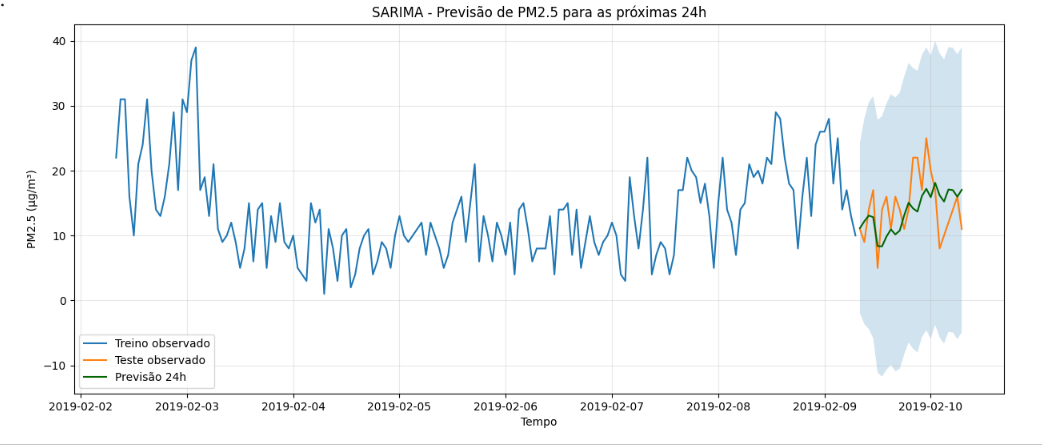

Experimento 02: 70% dos dados, sem interpolação, todas as features (temp, umi, prec, wind)

    order = (3,1,1)
    seasonal_order = (0,1,1,24)

Intevalo de treino: 2017-03-15 13:00:00+00:00 a 2018-11-25 09:00:00+00:00
relativedelta(years=+1, months=+8, days=+9, hours=+20)

Intevalo de teste: 2018-11-25 10:00:00+00:00 a 2018-11-25 10:00:00+00:00
relativedelta(months=+8, days=+23, hours=+16)

Baseline 24h - MAE : 5.250
Baseline 24h - RMSE: 6.545
Baseline 24h - R²  : -1.012

Test error (mae): 4.619873819737175
Test error (RMSE): 5.235
R²: -0.0961

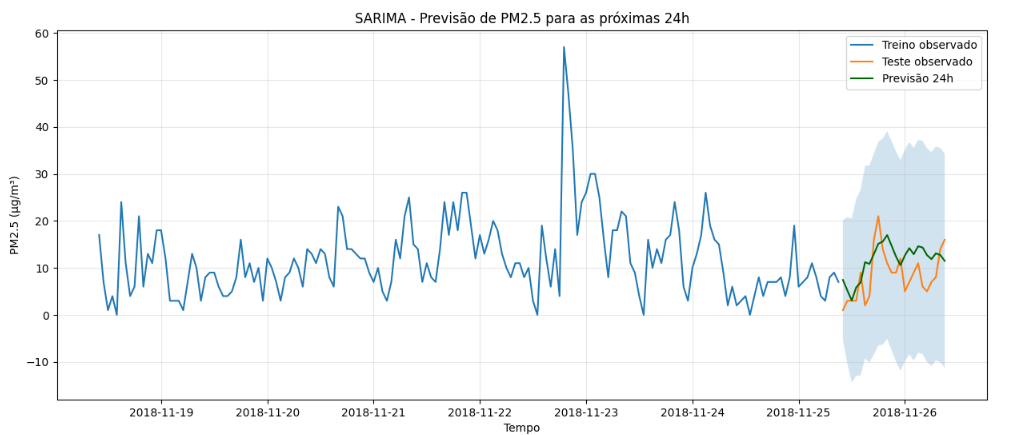

Experimento 03: 90% dos dados, sem interpolação, todas as features (temp, umi, prec, wind)

    order = (3,1,1)
    seasonal_order = (0,1,1,24)

Intevalo de treino: 2016-07-05 13:00:00+00:00 a 2018-09-10 12:00:00+00:00
relativedelta(years=+2, months=+2, days=+4, hours=+23)

Intevalo de teste: 2018-09-10 13:00:00+00:00 a 2018-09-10 13:00:00+00:00
relativedelta(months=+11, days=+7, hours=+13)

Baseline 24h - MAE : 6.875
Baseline 24h - RMSE: 8.254
Baseline 24h - R²  : -0.658


Test error (mae): 5.5783985978659745
Test error (RMSE): 6.582
R²: -0.0237

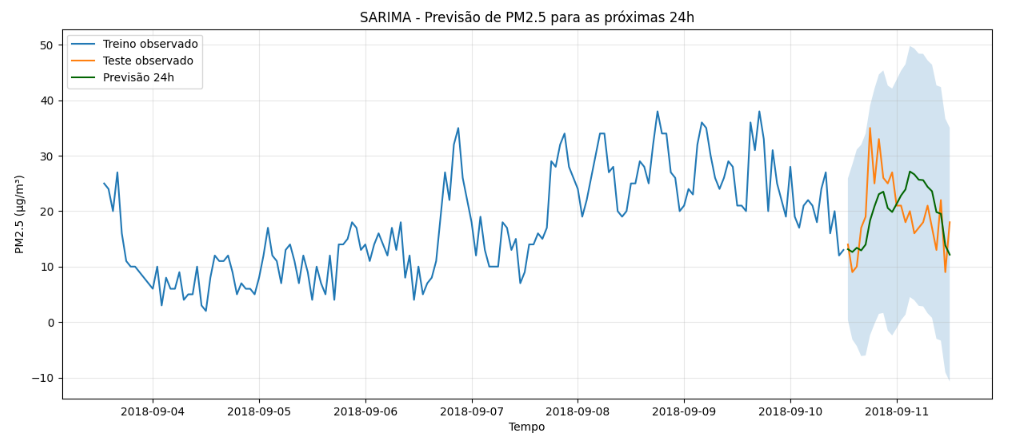

Experimento 03: 40% dos dados, sem interpolação, todas as features (temp, umi, prec, wind)

    order = (3,1,1)
    seasonal_order = (0,1,1,24)

Intevalo de treino: 2018-03-30 02:00:00+00:00 a 2019-03-19 06:00:00+00:00
relativedelta(months=+11, days=+19, hours=+4)

Intevalo de teste: 2019-03-19 07:00:00+00:00 a 2019-03-19 07:00:00+00:00
relativedelta(months=+4, days=+29, hours=+19)

Baseline 24h - MAE : 5.083
Baseline 24h - RMSE: 6.021
Baseline 24h - R²  : -2.677

Test error (mae): 3.277808058620666
Test error (RMSE): 4.032
R²: -0.1827

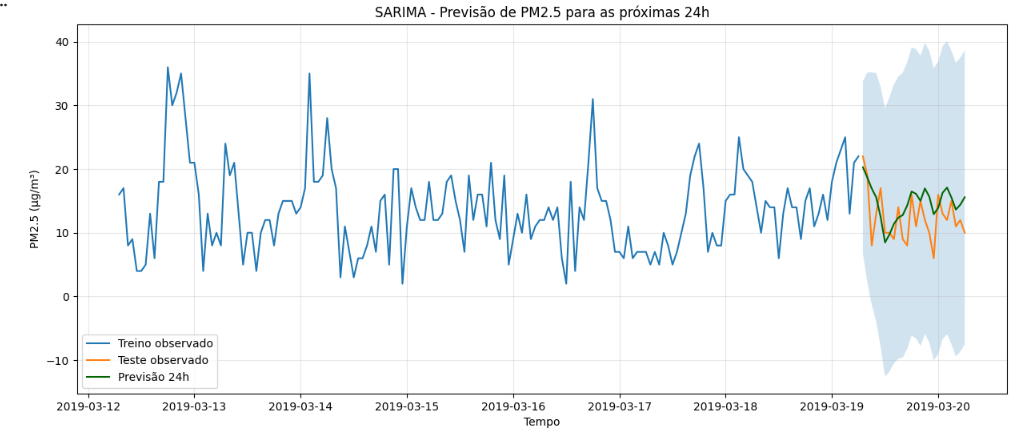

Experimento 04: 45% dos dados, sem interpolação, todas as features (temp, umi, prec, wind)

    order = (3,1,1)
    seasonal_order = (0,1,1,24)

Intevalo de treino: 2018-01-25 20:00:00+00:00 a 2019-02-28 07:00:00+00:00
relativedelta(years=+1, months=+1, days=+2, hours=+11)

Intevalo de teste: 2019-02-28 08:00:00+00:00 a 2019-02-28 08:00:00+00:00
relativedelta(months=+5, days=+20, hours=+18)

Baseline 24h - MAE : 4.958
Baseline 24h - RMSE: 5.827
Baseline 24h - R²  : -1.412

Test error (mae): 4.668236545228454
Test error (RMSE): 5.379
R²: -1.1725

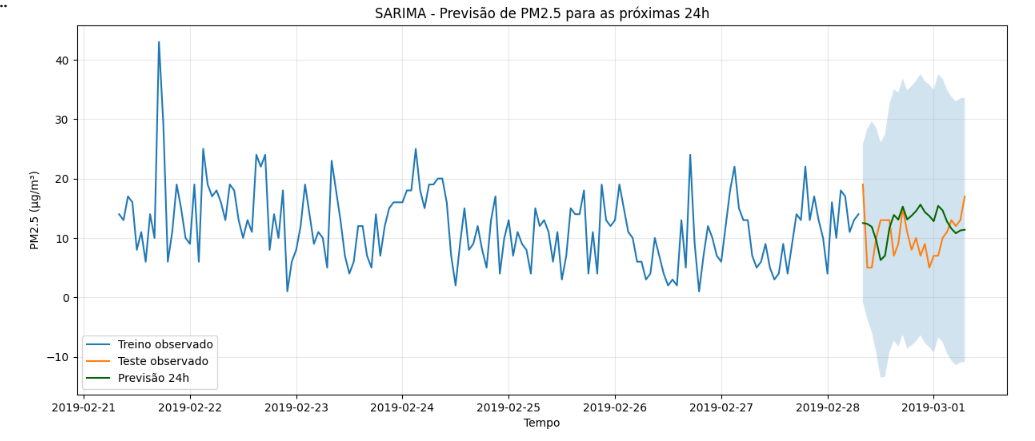

Experimento 05: 100% dos dados, sem interpolação, todas as features (temp, umi, prec, wind)

    order = (3,1,1)
    seasonal_order = (0,1,1,24)

Intevalo de treino: 2016-03-01 00:00:00+00:00 a 2018-08-03 13:00:00+00:00
relativedelta(years=+2, months=+5, days=+2, hours=+13)

Intevalo de teste: 2018-08-03 14:00:00+00:00 a 2018-08-03 14:00:00+00:00
relativedelta(years=+1, days=+14, hours=+12)


Baseline 24h - MAE : 5.208
Baseline 24h - RMSE: 6.374
Baseline 24h - R²  : -0.506

Test error (mae): 11.582190787648733
Test error (RMSE): 12.846
R²: -5.1118

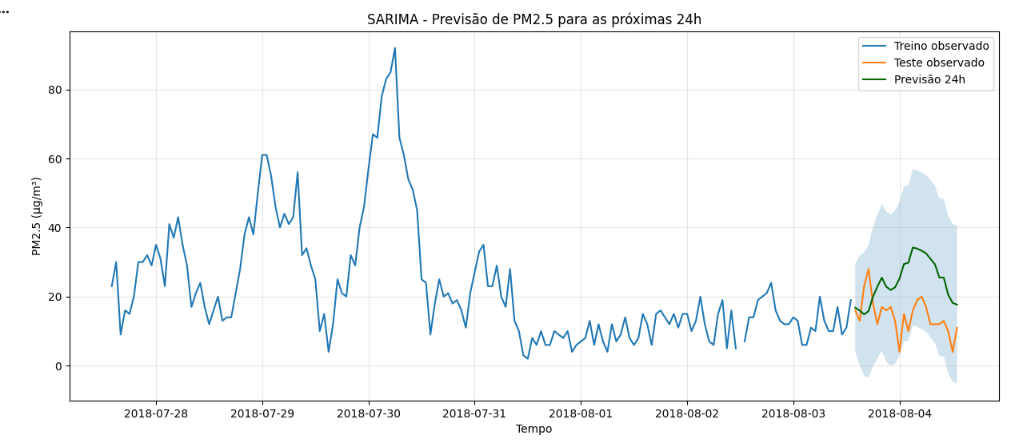